# 📓 Practical Jupyter Notebook — Feature Scaling

Standardization (`StandardScaler`) vs Min-Max Normalization (`MinMaxScaler`).

## Cell 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler

## Cell 2 — Create Dataset

In [2]:
data = {
    "age": [18, 20, 22, 25, 30, 35, 40],
    "salary": [20000, 25000, 30000, 45000, 60000, 90000, 150000],
    "experience": [0, 1, 2, 3, 5, 8, 12]
}

df = pd.DataFrame(data)

df

,age,salary,experience
0,18,20000,0
1,20,25000,1
2,22,30000,2
3,25,45000,3
4,30,60000,5
5,35,90000,8
6,40,150000,12


## Cell 3 — Check Dataset

In [3]:
print("----- First 5 Rows -----")
print(df.head())

print("\n----- Shape -----")
print(df.shape)

print("\n----- Data Types -----")
print(df.dtypes)

print("\n----- Statistical Summary -----")
print(df.describe())

----- First 5 Rows -----
   age  salary  experience
0   18   20000           0
1   20   25000           1
2   22   30000           2
3   25   45000           3
4   30   60000           5

----- Shape -----
(7, 3)

----- Data Types -----
age           int64
salary        int64
experience    int64
dtype: object

----- Statistical Summary -----
             age         salary  experience
count   7.000000       7.000000    7.000000
mean   27.142857   60000.000000    4.428571
std     8.173709   46457.866216    4.276180
min    18.000000   20000.000000    0.000000
25%    21.000000   27500.000000    1.500000
50%    25.000000   45000.000000    3.000000
75%    32.500000   75000.000000    6.500000
max    40.000000  150000.000000   12.000000


Notice karo:

- age → small values
- salary → large values
- experience → medium values

Inka scale different hai.

## Cell 4 — Visualize Before Scaling

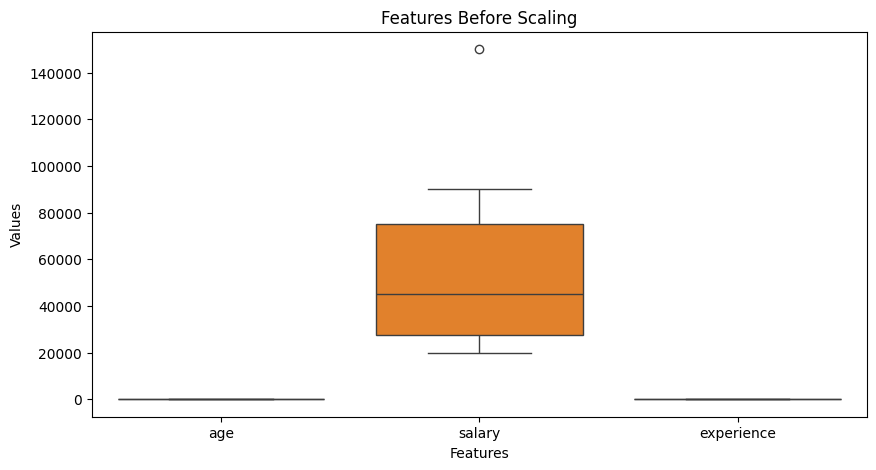

In [4]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df)

plt.title("Features Before Scaling")
plt.xlabel("Features")
plt.ylabel("Values")

plt.show()

Salary ka scale bahut bada hai, isliye comparison difficult ho sakta hai.

## Cell 5 — Standardization

In [5]:
standard_scaler = StandardScaler()

df_standardized = standard_scaler.fit_transform(df)

df_standardized = pd.DataFrame(
    df_standardized,
    columns=df.columns
)

df_standardized

,age,salary,experience
0,-1.208193,-0.929981,-1.118616
1,-0.943900,-0.813733,-0.866025
2,-0.679608,-0.697486,-0.613435
3,-0.283170,-0.348743,-0.360844
4,0.377560,0.000000,0.144338
5,1.038290,0.697486,0.902110
6,1.699021,2.092457,1.912473


Exact values dataset ke according calculate honge.

## Cell 6 — Check Mean

Standardization ke baad mean approximately 0 hona chahiye.

In [6]:
print("Mean after Standardization:")

print(df_standardized.mean())

Mean after Standardization:
age           1.268826e-16
salary       -6.344132e-17
experience   -9.516197e-17
dtype: float64


Expected: age ≈ 0, salary ≈ 0, experience ≈ 0

## Cell 7 — Check Standard Deviation

`StandardScaler` population std (`ddof=0`) use karta hai, jabki pandas `.std()` by default sample std (`ddof=1`) deta hai. Isliye yahan `ddof=0` pass kiya hai, tabhi result exactly 1 aayega.

In [7]:
print("Standard Deviation after Standardization:")

print(df_standardized.std(ddof=0))

Standard Deviation after Standardization:
age           1.0
salary        1.0
experience    1.0
dtype: float64


Approximately: age ≈ 1, salary ≈ 1, experience ≈ 1

## Cell 8 — Min-Max Normalization

In [8]:
minmax_scaler = MinMaxScaler()

df_normalized = minmax_scaler.fit_transform(df)

df_normalized = pd.DataFrame(
    df_normalized,
    columns=df.columns
)

df_normalized

,age,salary,experience
0,0.000000,0.000000,0.000000
1,0.090909,0.038462,0.083333
2,0.181818,0.076923,0.166667
3,0.318182,0.192308,0.250000
4,0.545455,0.307692,0.416667
5,0.772727,0.538462,0.666667
6,1.000000,1.000000,1.000000


Ab har feature generally `0 ≤ value ≤ 1` range mein hoga.

## Cell 9 — Check Minimum

In [9]:
print("Minimum values:")

print(df_normalized.min())

Minimum values:
age           0.0
salary        0.0
experience    0.0
dtype: float64


Expected: age 0, salary 0, experience 0

## Cell 10 — Check Maximum

In [10]:
print("Maximum values:")

print(df_normalized.max())

Maximum values:
age           1.0
salary        1.0
experience    1.0
dtype: float64


Expected: age 1, salary 1, experience 1

## Cell 11 — Compare All Three

In [11]:
comparison = pd.DataFrame({
    "Original Age": df["age"],
    "Standardized Age": df_standardized["age"],
    "Normalized Age": df_normalized["age"]
})

comparison

,Original Age,Standardized Age,Normalized Age
0,18,-1.208193,0.000000
1,20,-0.943900,0.090909
2,22,-0.679608,0.181818
3,25,-0.283170,0.318182
4,30,0.377560,0.545455
5,35,1.038290,0.772727
6,40,1.699021,1.000000


Isse clearly pata chalega ki same feature ki values scaling ke baad kaise change hui.

## Cell 12 — Visualization After Standardization

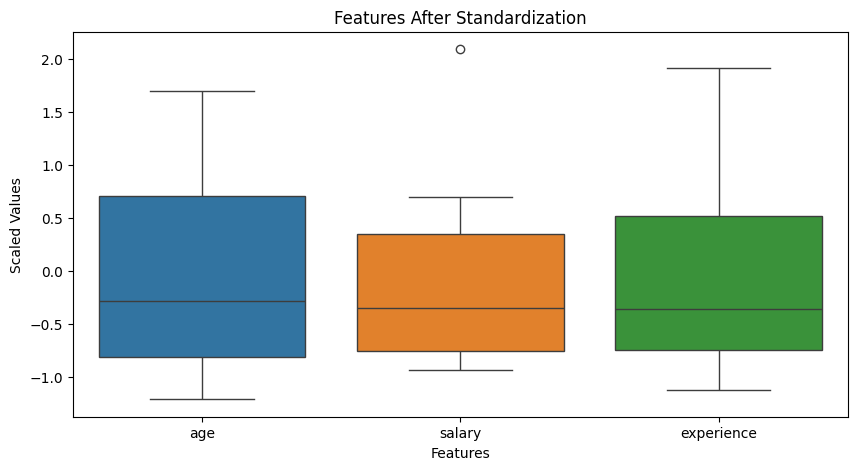

In [12]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df_standardized)

plt.title("Features After Standardization")
plt.xlabel("Features")
plt.ylabel("Scaled Values")

plt.show()

## Cell 13 — Visualization After Normalization

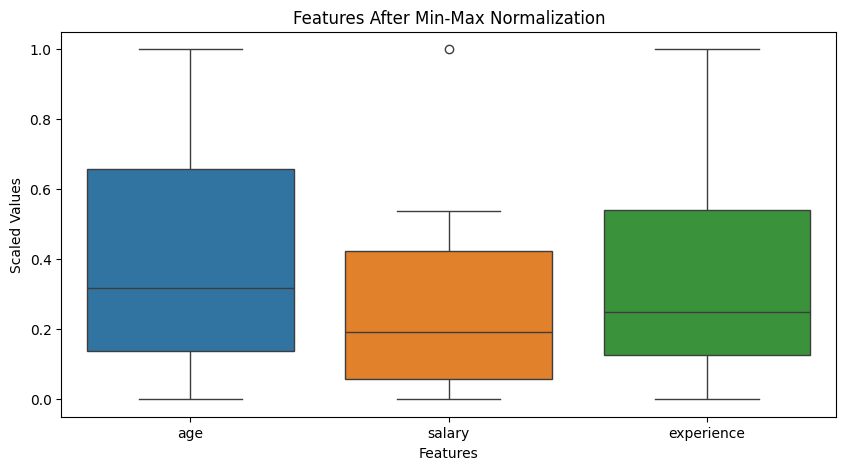

In [13]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df_normalized)

plt.title("Features After Min-Max Normalization")
plt.xlabel("Features")
plt.ylabel("Scaled Values")

plt.show()

## Cell 14 — StandardScaler with Train/Test Split

Real ML project mein ye method use karna important hai.

In [14]:
from sklearn.model_selection import train_test_split

X = df.copy()

X_train, X_test = train_test_split(
    X,
    test_size=0.2,
    random_state=42
)

print("Training Data:")
print(X_train)

print("\nTesting Data:")
print(X_test)

Training Data:
   age  salary  experience
5   35   90000           8
2   22   30000           2
4   30   60000           5
3   25   45000           3
6   40  150000          12

Testing Data:
   age  salary  experience
0   18   20000           0
1   20   25000           1


## Cell 15 — Correct Standardization

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

print("Scaled Training Data:")
print(X_train_scaled)

print("\nScaled Testing Data:")
print(X_test_scaled)

Scaled Training Data:
        age    salary  experience
0  0.704448  0.353553    0.550482
1 -1.286384 -1.060660   -1.100964
2 -0.061256 -0.353553   -0.275241
3 -0.826961 -0.707107   -0.825723
4  1.470153  1.767767    1.651446

Scaled Testing Data:
        age    salary  experience
0 -1.898948 -1.296362   -1.651446
1 -1.592666 -1.178511   -1.376205


**Important:**

- `scaler.fit_transform(X_train)` → Training data se scaling parameters learn karta hai.
- `scaler.transform(X_test)` → Same learned parameters test data par apply karta hai.

## Cell 16 — Save Scaled Dataset

In [16]:
df_standardized.to_csv(
    "standardized_data.csv",
    index=False
)

df_normalized.to_csv(
    "normalized_data.csv",
    index=False
)

print("Scaled datasets saved successfully!")

Scaled datasets saved successfully!


## 🧠 Final Revision

```
Feature Scaling
       ↓
Numerical Features ko Similar Scale par lana
       ↓
 ┌──────────────────────┐
 │                      │
Standardization      Normalization
 │                      │
 ↓                      ↓
StandardScaler       MinMaxScaler
 │                      │
Mean = 0              Range = 0 to 1
Std = 1
```

**Sabse important formulas**

Standardization:

$$ z = \frac{x-\mu}{\sigma} $$

Min-Max Normalization:

$$ x' = \frac{x-x_{min}}{x_{max}-x_{min}} $$

## 🧠 One-line memory

Standardization → mean 0, std 1 | Normalization → range 0 to 1